#Convert extracted 3D nodule patches into standardized CNN-ready images.

##1. Mount Drive

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


##2. Imports

In [2]:
import os
import random

from pathlib import Path

import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

##3. Define Paths

In [3]:
# ============================================================
# Paths
# ============================================================

BASE_PATH = Path("/content/drive/MyDrive/Dissertation/Dataset")

PROCESSED_PATH = BASE_PATH / "Processed"

PATCH_PATH = PROCESSED_PATH / "NodulePatches"

MASK_PATH = PROCESSED_PATH / "NoduleMasks"

CNN_PATH = PROCESSED_PATH / "CNN_Dataset"

BENIGN_PATH = CNN_PATH / "Benign"

MALIGNANT_PATH = CNN_PATH / "Malignant"

BENIGN_PATH.mkdir(parents=True, exist_ok=True)

MALIGNANT_PATH.mkdir(parents=True, exist_ok=True)

print(CNN_PATH)

/content/drive/MyDrive/Dissertation/Dataset/Processed/CNN_Dataset


##4. Load Dataset

In [4]:
dataset = pd.read_csv(
    PROCESSED_PATH / "nodule_dataset.csv"
)

print("Dataset shape:", dataset.shape)

dataset.head()

Dataset shape: (145, 11)


,PatientID,NoduleID,PatchPath,PatchShape,Readers,MeanMalignancy,MedianMalignancy,CancerLabel,MaskedPatchPath,MaskPath,MaskVoxelCount
0,LIDC-IDRI-0001,1,/content/drive/MyDrive/Dissertation/Dataset/Pr...,"(92, 84, 13)",4,4.75,5.0,1,/content/drive/MyDrive/Dissertation/Dataset/Pr...,/content/drive/MyDrive/Dissertation/Dataset/Pr...,5428
1,LIDC-IDRI-0002,1,/content/drive/MyDrive/Dissertation/Dataset/Pr...,"(85, 90, 32)",2,4.50,4.5,1,/content/drive/MyDrive/Dissertation/Dataset/Pr...,/content/drive/MyDrive/Dissertation/Dataset/Pr...,14252
2,LIDC-IDRI-0003,1,/content/drive/MyDrive/Dissertation/Dataset/Pr...,"(76, 74, 12)",1,2.00,2.0,0,/content/drive/MyDrive/Dissertation/Dataset/Pr...,/content/drive/MyDrive/Dissertation/Dataset/Pr...,2542
3,LIDC-IDRI-0003,2,/content/drive/MyDrive/Dissertation/Dataset/Pr...,"(80, 85, 14)",4,4.25,4.5,1,/content/drive/MyDrive/Dissertation/Dataset/Pr...,/content/drive/MyDrive/Dissertation/Dataset/Pr...,3241
4,LIDC-IDRI-0003,3,/content/drive/MyDrive/Dissertation/Dataset/Pr...,"(53, 59, 8)",4,3.25,3.5,0,/content/drive/MyDrive/Dissertation/Dataset/Pr...,/content/drive/MyDrive/Dissertation/Dataset/Pr...,261


##5. Verify Dataset

In [5]:
print(dataset.columns.tolist())

print()

print(dataset.isnull().sum())

['PatientID', 'NoduleID', 'PatchPath', 'PatchShape', 'Readers', 'MeanMalignancy', 'MedianMalignancy', 'CancerLabel', 'MaskedPatchPath', 'MaskPath', 'MaskVoxelCount']

PatientID           0
NoduleID            0
PatchPath           0
PatchShape          0
Readers             0
MeanMalignancy      0
MedianMalignancy    0
CancerLabel         0
MaskedPatchPath     0
MaskPath            0
MaskVoxelCount      0
dtype: int64


##6. Create Output Directories

In [6]:
print("Benign folder:")

print(BENIGN_PATH)

print()

print("Malignant folder:")

print(MALIGNANT_PATH)

Benign folder:
/content/drive/MyDrive/Dissertation/Dataset/Processed/CNN_Dataset/Benign

Malignant folder:
/content/drive/MyDrive/Dissertation/Dataset/Processed/CNN_Dataset/Malignant


##7. Utility Functions

####HU Normalization

In [7]:
def normalize_roi(image):
    """
    Adaptive normalization for cropped nodules.
    """

    image = image.astype(np.float32)

    p2 = np.percentile(image, 2)
    p98 = np.percentile(image, 98)

    image = np.clip(image, p2, p98)

    image = (image - p2) / (p98 - p2 + 1e-8)

    image = (image * 255)

    return image.astype(np.uint8)

####Mask Format Independence

In [8]:
def ensure_boolean_mask(mask):
    """
    Convert any stored mask to boolean.

    Handles:
    bool
    uint8 (0/1)
    uint8 (0/255)
    """

    return mask > 0

####Largest mask slice

In [9]:
def largest_mask_slice(mask):

    areas = []

    for i in range(mask.shape[2]):

        areas.append(mask[:, :, i].sum())

    return int(np.argmax(areas))

####Tight Crop

In [10]:
def tight_crop(patch, mask, padding=5):

    coords = np.argwhere(mask)

    y0, x0, z0 = coords.min(axis=0)

    y1, x1, z1 = coords.max(axis=0) + 1

    y0 = max(0, y0 - padding)
    x0 = max(0, x0 - padding)
    z0 = max(0, z0 - 1)

    y1 = min(mask.shape[0], y1 + padding)
    x1 = min(mask.shape[1], x1 + padding)
    z1 = min(mask.shape[2], z1 + 1)

    return (
        patch[y0:y1, x0:x1, z0:z1],
        mask[y0:y1, x0:x1, z0:z1]
    )

##8. Test One Sample

####8.1. Load One Sample

In [11]:
# ============================================================
# Load one sample
# ============================================================

sample = dataset.iloc[0]

patch = np.load(sample["PatchPath"])

mask = np.load(sample["MaskPath"])

print("Patient :", sample["PatientID"])
print("Label   :", sample["CancerLabel"])
print()

print("Patch shape:", patch.shape)
print("Mask shape :", mask.shape)

Patient : LIDC-IDRI-0001
Label   : 1

Patch shape: (92, 84, 13)
Mask shape : (92, 84, 13)


####8.2 Tight Crop

In [12]:
# ============================================================
# Crop tightly around the segmented nodule
# ============================================================

cropped_patch, cropped_mask = tight_crop(
    patch,
    mask,
    padding=5
)

print("Original :", patch.shape)

print("Cropped  :", cropped_patch.shape)

Original : (92, 84, 13)
Cropped  : (55, 47, 10)


####8.3 Largest tumor slice

In [13]:
# ============================================================
# Select the slice containing the largest tumour area
# ============================================================

best_slice = largest_mask_slice(cropped_mask)

print("Largest mask slice:", best_slice)

Largest mask slice: 4


####8.4 Visualize crop

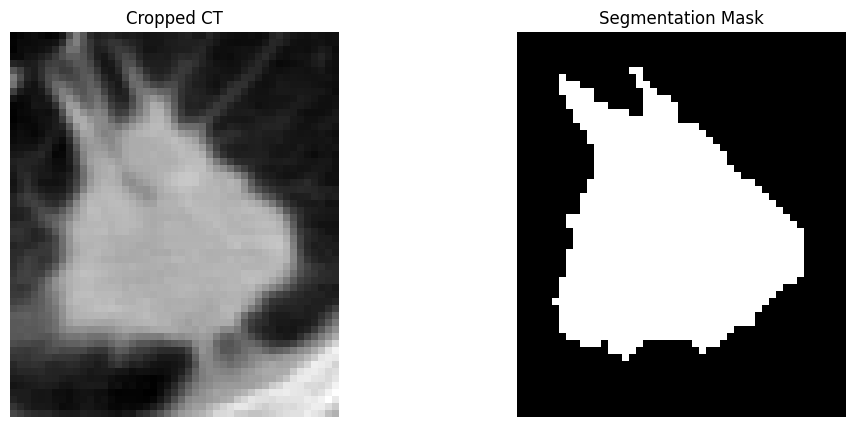

In [14]:
# ============================================================
# Visualize cropped patch and mask
# ============================================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.imshow(
    cropped_patch[:,:,best_slice],
    cmap="gray"
)

plt.title("Cropped CT")

plt.axis("off")


plt.subplot(1,2,2)

plt.imshow(
    cropped_mask[:,:,best_slice],
    cmap="gray"
)

plt.title("Segmentation Mask")

plt.axis("off")

plt.show()

##9. Apply Mask
####9.1 Apply segmentation mask

In [15]:
# Convert to boolean mask
cropped_mask = cropped_mask.astype(bool)

masked_patch = cropped_patch.copy()

masked_patch[~cropped_mask] = -1024

####9.2 Visualize the nodule after surrounding tissue removed.

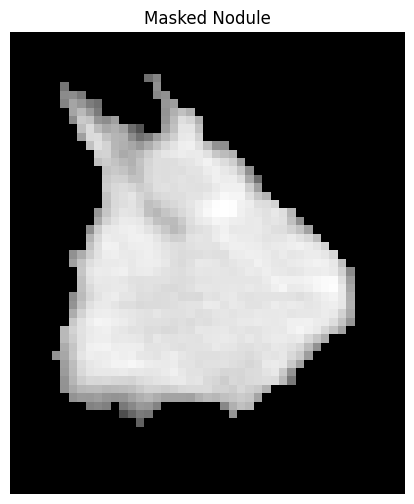

In [16]:
plt.figure(figsize=(6,6))

plt.imshow(
    masked_patch[:,:,best_slice],
    cmap="gray"
)

plt.title("Masked Nodule")

plt.axis("off")

plt.show()

##10. HU Normalization

In [18]:
normalized = normalize_roi(
    masked_patch[:,:,best_slice]
)

print(normalized.min())

print(normalized.max())

0
255


####10.1 Visualize HU Slice

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(
    normalized,
    cmap="gray"
)

plt.title("Normalized HU")

plt.axis("off")

plt.show()

##10. Pad to a square

####11.1 Add a helper function

In [ ]:
def pad_to_square(image):

    h, w = image.shape

    size = max(h, w)

    padded = np.zeros((size, size), dtype=image.dtype)

    y = (size - h) // 2

    x = (size - w) // 2

    padded[y:y+h, x:x+w] = image

    return padded

####11.2 Padded Image Shape

In [ ]:
square = pad_to_square(normalized)

print(square.shape)

####11.3 Visualize Padded Image

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(
    square,
    cmap="gray"
)

plt.title("Square Image")

plt.axis("off")

plt.show()

##12. Resize

In [ ]:
cnn_image = cv2.resize(
    square,
    (224,224),
    interpolation=cv2.INTER_CUBIC
)

print(cnn_image.shape)

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(
    cnn_image,
    cmap="gray"
)

plt.title("CNN Input")

plt.axis("off")

plt.show()

##13. Convert to RGB
####13.1 RGB Shape

In [ ]:
rgb = np.stack(
    [cnn_image, cnn_image, cnn_image],
    axis=-1
)

print(rgb.shape)

####13.2 Visualize Final CNN Image

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(rgb)

plt.title("Final CNN Image")

plt.axis("off")

plt.show()

##14. Create output Folders

In [ ]:
# ============================================================
# Create final CNN dataset folders
# ============================================================

CNN_DATASET = PROCESSED_PATH / "CNN_Dataset"

BENIGN_DIR = CNN_DATASET / "Benign"

MALIGNANT_DIR = CNN_DATASET / "Malignant"

BENIGN_DIR.mkdir(parents=True, exist_ok=True)

MALIGNANT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset directory:", CNN_DATASET)

##15. Final PreProcessing Function

In [ ]:
def preprocess_nodule(patch_path, mask_path):
    """
    Complete preprocessing pipeline
    """

    # ------------------------------------
    # Load
    # ------------------------------------

    patch = np.load(patch_path)

    mask = np.load(mask_path)

    mask = mask.astype(bool)

    # ------------------------------------
    # Tight crop
    # ------------------------------------

    patch, mask = tight_crop(
        patch,
        mask,
        padding=5
    )

    # ------------------------------------
    # Largest nodule slice
    # ------------------------------------

    best = largest_mask_slice(mask)

    image = patch[:, :, best]

    # ------------------------------------
    # IMPORTANT:
    # DO NOT REMOVE LUNG TISSUE
    # ------------------------------------

    # image[~mask[:,:,best]] = -1024
    # <--- DELETE THIS

    # ------------------------------------
    # HU normalization
    # ------------------------------------

    image = normalize_roi(image)

    # ------------------------------------
    # CLAHE
    # ------------------------------------

    clahe = cv2.createCLAHE(
        clipLimit=1.5,
        tileGridSize=(4,4)
    )

    image = clahe.apply(image)

    # ------------------------------------
    # Square padding
    # ------------------------------------

    image = pad_to_square(image)

    # ------------------------------------
    # Resize
    # ------------------------------------

    image = cv2.resize(
        image,
        (128,128),
        interpolation=cv2.INTER_AREA
    )

    # ------------------------------------
    # RGB
    # ------------------------------------

    rgb = cv2.cvtColor(
        image,
        cv2.COLOR_GRAY2RGB
    )

    return rgb

##16. Test the Pipeline

In [ ]:
sample = dataset.iloc[0]

rgb = preprocess_nodule(
    sample.PatchPath,
    sample.MaskPath
)

plt.figure(figsize=(6,6))

plt.imshow(rgb)

plt.title("Final CNN Input")

plt.axis("off")

plt.show()

print(rgb.shape)

##17. Process Entire Dataset

In [ ]:
from tqdm.auto import tqdm

records = []

for row in tqdm(
    dataset.itertuples(index=False),
    total=len(dataset),
    desc="Processing nodules"
):

    rgb = preprocess_nodule(
        row.PatchPath,
        row.MaskPath
    )

    if row.CancerLabel == 0:

        save_dir = BENIGN_DIR

        label_name = "Benign"

    else:

        save_dir = MALIGNANT_DIR

        label_name = "Malignant"

    filename = f"{row.PatientID}_Nodule_{int(row.NoduleID):03d}.png"

    save_path = save_dir / filename

    cv2.imwrite(
        str(save_path),
        cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    )

    records.append({

        "PatientID": row.PatientID,

        "NoduleID": row.NoduleID,

        "CancerLabel": row.CancerLabel,

        "LabelName": label_name,

        "ImagePath": str(save_path)

    })

##18. Create Final Dataset

In [ ]:
cnn_dataset = pd.DataFrame(records)

cnn_dataset.head()

##19. Save CSV

In [ ]:
csv_path = PROCESSED_PATH / "cnn_dataset.csv"

cnn_dataset.to_csv(
    csv_path,
    index=False
)

print(csv_path)

##20. Verify Dataset

In [ ]:
print("Dataset shape:")

print(cnn_dataset.shape)

print()

print("Class distribution:")

print(
    cnn_dataset["LabelName"].value_counts()
)

##21. Verify Files

In [ ]:
missing = []

for path in cnn_dataset.ImagePath:

    if not Path(path).exists():

        missing.append(path)

print("Missing images:", len(missing))

##22. Inspect Random Samples

In [ ]:
import random

indices = random.sample(
    range(len(cnn_dataset)),
    min(9, len(cnn_dataset))
)

plt.figure(figsize=(12,12))

for i, idx in enumerate(indices):

    img = cv2.imread(cnn_dataset.iloc[idx].ImagePath)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    label = cnn_dataset.iloc[idx].LabelName

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(label)

    plt.axis("off")

plt.tight_layout()

plt.show()

##23. Dataset Statistics

In [ ]:
print("=" * 50)

print("Total images :", len(cnn_dataset))

print()

print(cnn_dataset["LabelName"].value_counts())

print()

print("Image shape:")

sample = cv2.imread(
    cnn_dataset.iloc[0].ImagePath,
    cv2.IMREAD_COLOR
)

sample = cv2.cvtColor(
    sample,
    cv2.COLOR_BGR2RGB
)

print(sample.shape)

print()

print("Data type:", sample.dtype)

print()

print("Pixel range:")

print(sample.min(), sample.max())

print("=" * 50)

In [ ]:
sample = dataset[dataset["CancerLabel"] == 0].iloc[0]

patch = np.load(sample.PatchPath)
mask = np.load(sample.MaskPath).astype(bool)

patch, mask = tight_crop(patch, mask, padding=5)

best = largest_mask_slice(mask)

image = patch[:, :, best]
mask2d = mask[:, :, best]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image, cmap="gray")
plt.title("Original CT Slice")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask2d, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(image, cmap="gray")
plt.contour(mask2d, colors="red", linewidths=1)
plt.title("Mask Overlay")
plt.axis("off")

plt.show()

print("Image shape:", image.shape)
print("Mask pixels:", mask2d.sum())

In [ ]:
print(cnn_dataset.shape)

print()

print(cnn_dataset["CancerLabel"].value_counts())

print()

print(cnn_dataset.isnull().sum())